insta_movie_to_photo.ipynbのファイルでInstagram動画を各アイドル画像に追加したのに、精度はすべて悪くなった。原因を特定したい

face_db loaded
Loaded face_db keys: ['menber_db/endou', 'menber_db/kaki', 'menber_db/yumiki', 'menber_db/umezawa', 'menber_db/suzuki', 'menber_db/ioki', 'menber_db/hayashi', 'menber_db/ikeda']


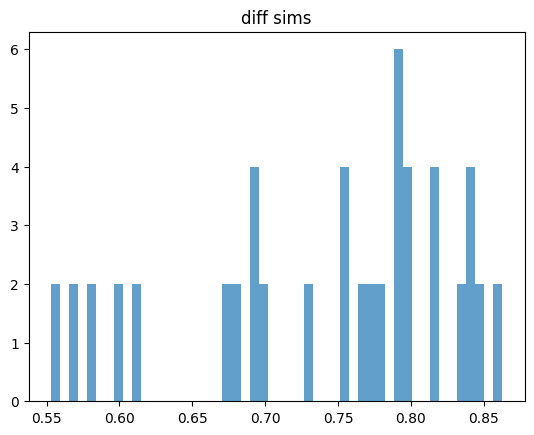

In [2]:
# 埋め込み類似度の差を見るためのコード
# 例: face_db, sample_imgs は既に読み込まれている前提
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import os
import pickle

# ランダムに同一人物ペアと異人物ペアを作る
# 次回以降は以下のように読み込みます
cache_dir = "./face_db_cache"
filename = "face_db_20260608_2303.pkl"  # 例: 保存したファイル名を指定
save_face_db_path = os.path.join(cache_dir, filename)

with open(save_face_db_path, "rb") as f:
    face_db = pickle.load(f)
print("face_db loaded")
print(f"Loaded face_db keys: {list(face_db.keys())}")

labels = list(face_db.keys())
embs = {k: np.array(v) for k,v in face_db.items()}

same_sims, diff_sims = [], []
for i,k in enumerate(labels):
    for j,k2 in enumerate(labels):
        if i==j: continue
        s = cosine_similarity(embs[k].reshape(1,-1), embs[k2].reshape(1,-1))[0,0]
        diff_sims.append(s)
    # 同一人物サンプルがあるなら追加（もし複数embeddingを保存していれば）
# もし評価画像の埋め込み(objs)があるなら:
# same_sims.append(cosine_similarity(embs[label], np.array(objs[0]['embedding']).reshape(1,-1))[0,0])

import matplotlib.pyplot as plt
plt.hist(diff_sims, bins=50, alpha=0.7); plt.title('diff sims')
plt.show()

labels: 8
diff mean/std: 0.7403398398694403 0.09021140797660895


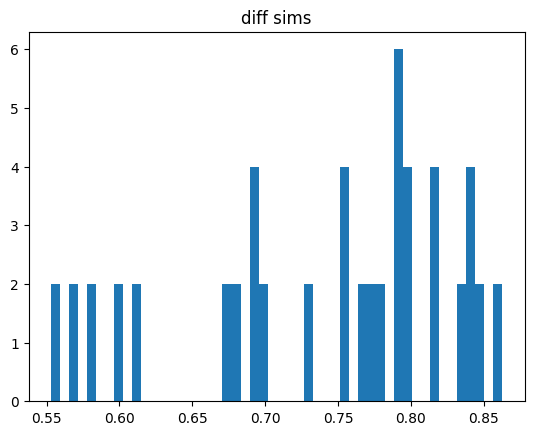

In [3]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pickle, os

# 読み込み（path を適宜変更）
with open("./face_db_cache/face_db_20260608_2303.pkl","rb") as f:
    face_db = pickle.load(f)
labels = list(face_db.keys())
embs = {k: np.array(v) for k,v in face_db.items()}

# 同一 vs 異ラベル類似度（同一はもし複数サンプルがあれば計算）
same_sims, diff_sims = [], []
for i, a in enumerate(labels):
    for j, b in enumerate(labels):
        if i==j: continue
        s = cosine_similarity(embs[a].reshape(1,-1), embs[b].reshape(1,-1))[0,0]
        diff_sims.append(s)

# 基本統計
print("labels:", len(labels))
print("diff mean/std:", np.mean(diff_sims), np.std(diff_sims))
plt.hist(diff_sims, bins=50); plt.title('diff sims'); plt.show()

# もし評価用の埋め込みリスト（eval_embs, eval_labels）があるならROC/AUC
# all_sims = []
# y_true = []
# for e_emb, e_label in zip(eval_embs, eval_labels):
#     for lab, lab_emb in embs.items():
#         all_sims.append(cosine_similarity(e_emb.reshape(1,-1), lab_emb.reshape(1,-1))[0,0])
#         y_true.append(1 if lab==e_label else 0)
# print('AUC', roc_auc_score(y_true, all_sims))

In [ ]:
# per-image -> own_median / best_other_median を計算して疑わしいサンプルを出力
import pickle, numpy as np
from sklearn.metrics.pairwise import cosine_similarity

p = r'./face_db_cache/face_db_clean_sampled_with_embs.pkl'
with open(p, 'rb') as f:
    data = pickle.load(f)
# data: {label: {'median':..., 'embs':[...]} } かもしれない。正規化：
db = {}
for k,v in data.items():
    if isinstance(v, dict) and 'embs' in v:
        db[k] = {'median': np.asarray(v['median']).reshape(-1), 'embs': [np.asarray(e).reshape(-1) for e in v['embs']]}
    elif isinstance(v, np.ndarray):
        db[k] = {'median': np.asarray(v).reshape(-1), 'embs': [np.asarray(v).reshape(-1)]}
    elif isinstance(v, list):
        # list-> assume list of 1D arrays
        db[k] = {'median': np.median(np.stack([np.asarray(e).reshape(-1) for e in v]), axis=0), 'embs':[np.asarray(e).reshape(-1) for e in v]}
    else:
        arr = np.asarray(v)
        if arr.ndim==1:
            db[k] = {'median': arr.reshape(-1), 'embs':[arr.reshape(-1)]}
        else:
            db[k] = {'median': np.median(arr, axis=0).reshape(-1), 'embs':[row.reshape(-1) for row in np.atleast_2d(arr)]}

# precompute medians matrix
labels = list(db.keys())
medians = {lab: db[lab]['median'] for lab in labels}

sus = []  # (lab, idx, own_sim, best_other_sim, best_other_lab)
for lab in labels:
    own_med = medians[lab].reshape(1,-1)
    for idx, emb in enumerate(db[lab]['embs']):
        e = emb.reshape(1,-1)
        own_sim = float(cosine_similarity(e, own_med)[0,0])
        # best other median
        best_other_sim = -1.0
        best_other_lab = None
        for olab in labels:
            if olab == lab: continue
            s = float(cosine_similarity(e, medians[olab].reshape(1,-1))[0,0])
            if s > best_other_sim:
                best_other_sim = s; best_other_lab = olab
        sus.append((lab, idx, own_sim, best_other_sim, best_other_lab))

# ソートして上位（自己類似が低く他類似が高い）を表示
sus_sorted = sorted(sus, key=lambda x: (x[2]-x[3]))  # 差が小さい/負なら危険
print("top suspicious (lab, idx, own_sim, best_other_sim, best_other_lab):")
for item in sus_sorted[:40]:
    print(item)

# 集計: 各ラベルの平均自己類似
for lab in labels:
    sims = [x[2] for x in sus if x[0]==lab]
    print(f"{lab}: count={len(sims)}, mean_own_sim={np.mean(sims):.4f}")

: 

In [1]:
import os, pickle, numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter

# ファイルパス（必要に応じて変更）
old_path = "./face_db_cache/face_db_20260608_2303.pkl"   # 追加前のmedianだけDB（存在すれば）
new_with_embs = "./face_db_cache/face_db_clean_sampled_with_embs.pkl"  # per-image保存版

old_db = {}
if os.path.exists(old_path):
    with open(old_path,'rb') as f: old_db = pickle.load(f)
with open(new_with_embs,'rb') as f: new_db = pickle.load(f)

# 正規化: old medians, new medians + per-image
old_meds = {os.path.basename(k): np.asarray(v).reshape(-1) for k,v in (old_db.items() if old_db else [])}
new_per = {}
new_meds = {}
for k,v in new_db.items():
    name = os.path.basename(k)
    if isinstance(v, dict) and 'embs' in v:
        embs = [np.asarray(e).reshape(-1) for e in v['embs']]
        new_per[name] = embs
        new_meds[name] = np.asarray(v.get('median', np.median(np.stack(embs),axis=0))).reshape(-1)
    elif isinstance(v, np.ndarray):
        new_meds[name] = np.asarray(v).reshape(-1)
        new_per[name] = [np.asarray(v).reshape(-1)]
    elif isinstance(v, list):
        embs = [np.asarray(e).reshape(-1) for e in v]
        new_per[name] = embs
        new_meds[name] = np.median(np.stack(embs), axis=0)

print("labels (new):", len(new_meds), "counts:", {k:len(v) for k,v in new_per.items()})
# median shift old->new
if old_meds:
    print("median shifts (cosine old vs new):")
    for lab in sorted(new_meds.keys()):
        if lab in old_meds:
            s = cosine_similarity(old_meds[lab].reshape(1,-1), new_meds[lab].reshape(1,-1))[0,0]
            print(f"  {lab}: {s:.4f}")
        else:
            print(f"  {lab}: missing in old_db")

# per-sample diagnostics: own_sim vs best_other_sim
labels = list(new_meds.keys())
sus = []
for lab in labels:
    med = new_meds[lab].reshape(1,-1)
    embs = new_per.get(lab, [])
    for i,e in enumerate(embs):
        e1 = np.asarray(e).reshape(1,-1)
        own = float(cosine_similarity(e1, med)[0,0])
        best_o = -1; best_lab=None
        for olab in labels:
            if olab==lab: continue
            s = float(cosine_similarity(e1, new_meds[olab].reshape(1,-1))[0,0])
            if s>best_o:
                best_o=s; best_lab=olab
        sus.append((lab,i,own,best_o,best_lab))
sus_sorted = sorted(sus, key=lambda x: (x[2]-x[3]))
print("\nTop suspicious samples (lab,idx,own, best_other, best_lab):")
for t in sus_sorted[:30]:
    print(t)

# class stats
for lab in labels:
    sims = [x[2] for x in sus if x[0]==lab]
    print(f"{lab}: count={len(sims)}, mean_own={np.mean(sims):.4f}, std={np.std(sims):.4f}")

ModuleNotFoundError: No module named 'numpy._core'

clean face_db saved, labels: 7
inter mean/std: 0.5970867137207848 0.11007176790763681
intra mean/std: (np.float64(0.5380293251682152), np.float64(0.24483687643290855))


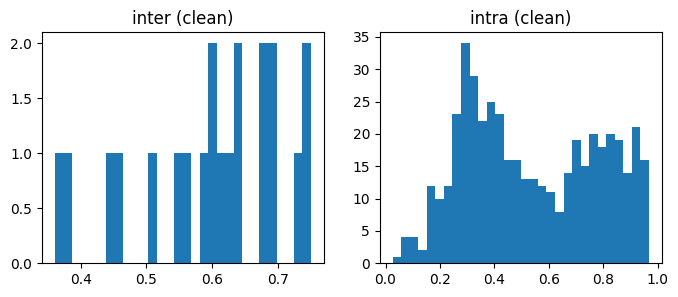

In [16]:
# サンプリング再構築（各ラベル最大N枚、'frame_'を除外）
import os, random, pickle, numpy as np
from deepface import DeepFace
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

base_dir = "./menber_db"   # メンバーフォルダ直下
model_name = "Facenet"
min_conf = 0.6
N = 5   # 各ラベルあたり再抽出する最大枚数（負荷調整：小さくするほど速い）

clean_means = {}
per_image_embs = {}  # label -> list of embeddings used

for label in sorted(os.listdir(base_dir)):
    labdir = os.path.join(base_dir, label)
    if not os.path.isdir(labdir): continue
    imgs = [f for f in os.listdir(labdir) if f.lower().endswith(('.jpg','.jpeg','.png')) and 'frame_' not in f]
    if not imgs: continue
    sample = random.sample(imgs, min(N, len(imgs)))
    embs = []
    for fn in sample:
        path = os.path.join(labdir, fn)
        try:
            objs = DeepFace.represent(img_path=path, model_name=model_name,
                                      detector_backend='retinaface', enforce_detection=False)
            for o in objs:
                if o.get('face_confidence',0) >= min_conf:
                    embs.append(np.array(o['embedding']))
        except Exception as e:
            print('err', path, e)
    if embs:
        per_image_embs[label] = embs
        # clean_means[label] = np.mean(np.stack(embs), axis=0) # 平均値
        clean_means[label] = np.median(np.stack(embs), axis=0) #中央値

# 保存（任意）
os.makedirs("./face_db_cache", exist_ok=True)
with open("./face_db_cache/face_db_clean_sampled.pkl","wb") as f:
    pickle.dump(clean_means, f)
print("clean face_db saved, labels:", len(clean_means))

# 評価: inter / intra
inter, intra = [], []
keys = list(clean_means.keys())
for i in range(len(keys)):
    for j in range(i+1,len(keys)):
        inter.append(cosine_similarity(clean_means[keys[i]].reshape(1,-1), clean_means[keys[j]].reshape(1,-1))[0,0])
for lab, L in per_image_embs.items():
    for i in range(len(L)):
        for j in range(i+1, len(L)):
            intra.append(cosine_similarity(L[i].reshape(1,-1), L[j].reshape(1,-1))[0,0])

print("inter mean/std:", np.mean(inter), np.std(inter))
print("intra mean/std:", (np.mean(intra) if intra else None, np.std(intra) if intra else None))
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); plt.hist(inter, bins=30); plt.title('inter (clean)')
plt.subplot(1,2,2); plt.hist(intra, bins=30); plt.title('intra (clean)')
plt.show()

要約

元（Instagram追加あり）: labels 8 — Inter mean/std = 0.7403 / 0.0902

注: 元データでは intra（ラベル内ペア統計）は未計算（face_db が代表1本のみのため）。
frame_ 除外・サンプリング（平均代表）: labels 7 — Inter mean/std = 0.6563 / 0.0893、Intra mean/std = 0.6366 / 0.1660

中央値代表に変更（frame_ 除外・サンプリング）: labels 7 — Inter mean/std = 0.6132 / 0.1058、Intra mean/std = 0.6745 / 0.1284

改善量（わかりやすく）

Inter (元 → 中央値): 0.7403 → 0.6132
絶対差: -0.1272（低下）
相対差: 約 -17.2%（異ラベル間の類似度が下がった = 改善）
Inter (平均代表 → 中央値): 0.6563 → 0.6132
絶対差: -0.0432（約 -6.6%）
Intra (平均代表 → 中央値): 0.6366 → 0.6745
絶対差: +0.0379（約 +6.0%） → 同一ラベル内の類似度が上がった（望ましい）
標準偏差の変化:
Inter std: 0.0893 → 0.1058（やや広がる）
Intra std: 0.1660 → 0.1284（狭くなる＝ラベル内が安定）

解釈（短く）

中央値代表に変えたことで「異ラベル類似度が下がり」「同ラベル類似度が上がる」良い効果が出ています。つまり中央値は外れ値やノイズに対して平均より頑健で、クラス分離が改善されました。
Inter の分布幅（std）が増えたのは、クラス間のばらつきが増えたことを示しますが平均値の低下（良い方向）が優勢です。

定義

intra（同ラベル内類似度）: 同じ人物の画像どうしの埋め込み類似度のこと。値が大きいほど「同一人物画像が似ている」。
inter（異ラベル間類似度）: 異なる人物同士の埋め込み類似度のこと。値が小さいほど「他人とよく分離されている」。

直感（たとえば顔認識で）

良い状態: 同一人物の写真は近く（高い intra）、別人の写真は遠い（低い inter）。
悪い状態: inter が高く intra が低い → 別人同士が似て見える、または同一内のバラつきが大きい。

数値の読み方（例）

望ましい: intra ≈ 0.8、inter ≈ 0.3 のように差が大きい。
今回のケース: 例えば inter≈0.61 / intra≈0.67 は分離が弱く改善の余地あり（理想は intra - inter が大きい）。

Loaded: ./face_db_cache/face_db_clean_sampled.pkl
1. umezawa <-> yumiki : sim=0.7833
   umezawa: 23 images, frames=0
   sample files: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg', '000006.jpg']
   yumiki: 60 images, frames=32
   sample files: ['000001.jpg', '000001_add.jpg', '000002.jpg', '000002_add.jpg', '000003.jpg', '000003_add.jpg']


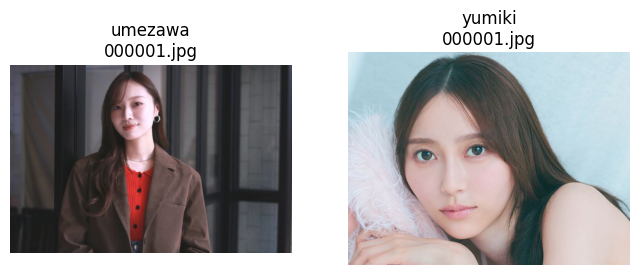

2. ioki <-> kaki : sim=0.7432
   ioki: 129 images, frames=38
   sample files: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg', '000006.jpg']
   kaki: 76 images, frames=46
   sample files: ['000001_add.jpg', '000002_add.jpg', '000003.jpg', '000003_add.jpg', '000004_add.jpg', '000005.jpg']


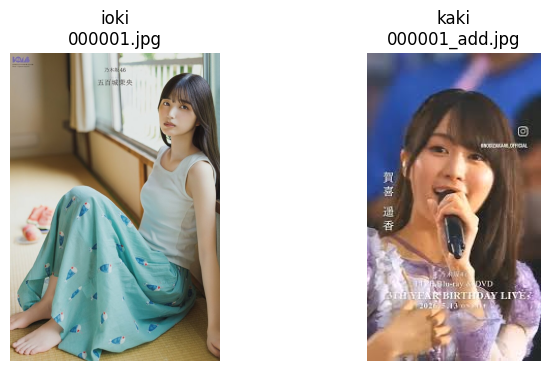

3. kaki <-> suzuki : sim=0.7029
   kaki: 76 images, frames=46
   sample files: ['000001_add.jpg', '000002_add.jpg', '000003.jpg', '000003_add.jpg', '000004_add.jpg', '000005.jpg']
   suzuki: 47 images, frames=30
   sample files: ['000001.jpg', '000001_add.jpg', '000002.jpg', '000002_add.jpg', '000003_add.jpg', '000004_add.jpg']


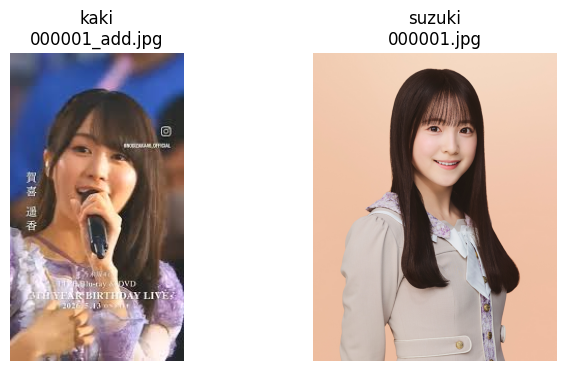

4. hayashi <-> kaki : sim=0.7024
   hayashi: 52 images, frames=24
   sample files: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg', '000006.jpg']
   kaki: 76 images, frames=46
   sample files: ['000001_add.jpg', '000002_add.jpg', '000003.jpg', '000003_add.jpg', '000004_add.jpg', '000005.jpg']


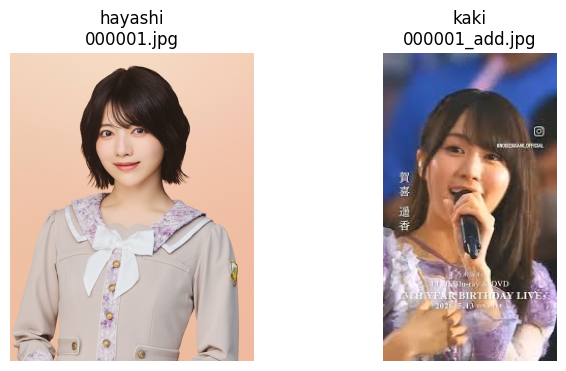

5. hayashi <-> suzuki : sim=0.7012
   hayashi: 52 images, frames=24
   sample files: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg', '000006.jpg']
   suzuki: 47 images, frames=30
   sample files: ['000001.jpg', '000001_add.jpg', '000002.jpg', '000002_add.jpg', '000003_add.jpg', '000004_add.jpg']


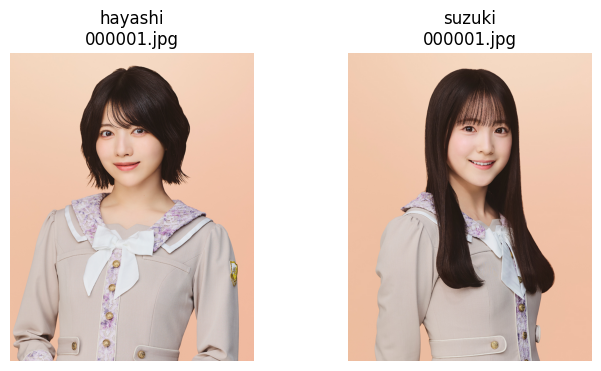

6. kaki <-> umezawa : sim=0.6928
   kaki: 76 images, frames=46
   sample files: ['000001_add.jpg', '000002_add.jpg', '000003.jpg', '000003_add.jpg', '000004_add.jpg', '000005.jpg']
   umezawa: 23 images, frames=0
   sample files: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg', '000006.jpg']


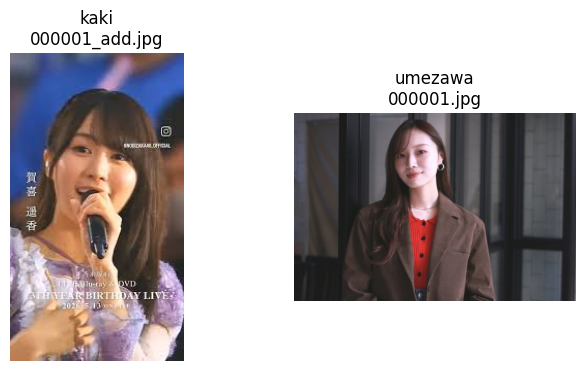

7. ioki <-> suzuki : sim=0.6811
   ioki: 129 images, frames=38
   sample files: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg', '000006.jpg']
   suzuki: 47 images, frames=30
   sample files: ['000001.jpg', '000001_add.jpg', '000002.jpg', '000002_add.jpg', '000003_add.jpg', '000004_add.jpg']


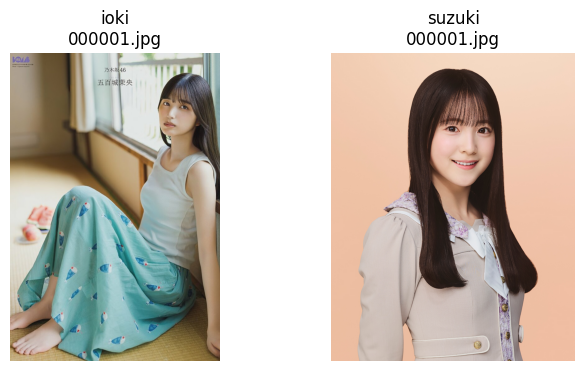

8. ioki <-> umezawa : sim=0.6610
   ioki: 129 images, frames=38
   sample files: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg', '000006.jpg']
   umezawa: 23 images, frames=0
   sample files: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg', '000006.jpg']


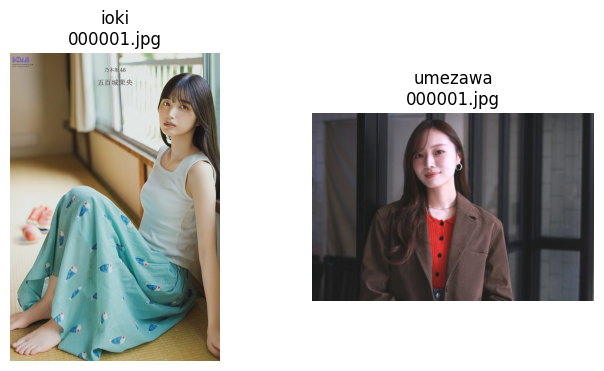

9. kaki <-> yumiki : sim=0.6499
   kaki: 76 images, frames=46
   sample files: ['000001_add.jpg', '000002_add.jpg', '000003.jpg', '000003_add.jpg', '000004_add.jpg', '000005.jpg']
   yumiki: 60 images, frames=32
   sample files: ['000001.jpg', '000001_add.jpg', '000002.jpg', '000002_add.jpg', '000003.jpg', '000003_add.jpg']


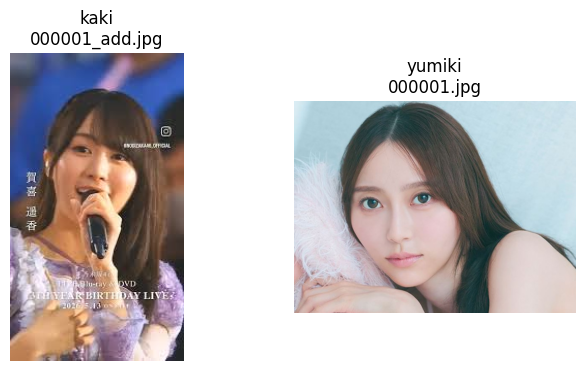

10. hayashi <-> ioki : sim=0.6324
   hayashi: 52 images, frames=24
   sample files: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg', '000006.jpg']
   ioki: 129 images, frames=38
   sample files: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg', '000006.jpg']


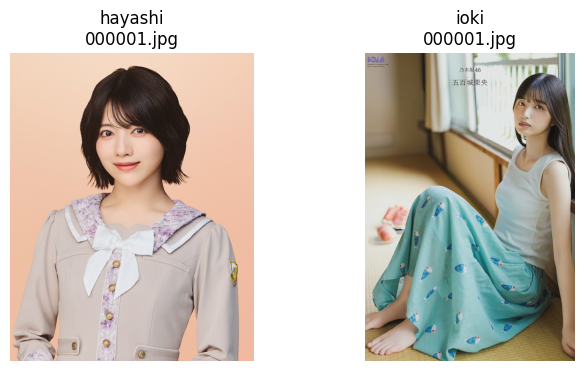

Done


In [14]:
# 高inter（類似度が高い）ペアの特定と可視化
import os, pickle, numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# face_db を読み込む（クリーン版優先）
candidates = [
    "./face_db_cache/face_db_clean_sampled.pkl",
    "./face_db_cache/face_db_20260608_2303.pkl",
]
face_db = None
for p in candidates:
    p_full = os.path.join("./face_db_cache", os.path.basename(p)) if not os.path.isabs(p) else p
    if os.path.exists(p):
        with open(p, "rb") as f:
            face_db = pickle.load(f)
        print("Loaded:", p)
        break

if face_db is None:
    raise FileNotFoundError("face_db が見つかりません。./face_db_cache を確認してください。")

labels = list(face_db.keys())
embs = {k: np.array(v) for k, v in face_db.items()}

# ラベル間類似度を計算して高い順でソート
pairs = []
for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        s = cosine_similarity(embs[labels[i]].reshape(1, -1), embs[labels[j]].reshape(1, -1))[0, 0]
        pairs.append((s, labels[i], labels[j]))

pairs.sort(reverse=True, key=lambda x: x[0])

# 上位を表示して、該当ラベルのサンプル画像とファイル一覧を表示
TOP_K = 10
base_dir = "./menber_db"
for idx, (s, a, b) in enumerate(pairs[:TOP_K], start=1):
    print(f"{idx}. {a} <-> {b} : sim={s:.4f}")
    for lab in (a, b):
        labdir = os.path.join(base_dir, lab)
        if os.path.isdir(labdir):
            files = [f for f in os.listdir(labdir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            frame_count = sum(1 for f in files if 'frame_' in f)
            print(f"   {lab}: {len(files)} images, frames={frame_count}")
            print("   sample files:", files[:6])
        else:
            print("   dir not found:", labdir)

    # 代表画像を表示（見つかった最初の画像）
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    for ax, lab in zip(axs, (a, b)):
        labdir = os.path.join(base_dir, lab)
        shown = False
        if os.path.isdir(labdir):
            files = [f for f in os.listdir(labdir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            for fn in files:
                path = os.path.join(labdir, fn)
                try:
                    img = mpimg.imread(path)
                    ax.imshow(img)
                    ax.set_title(f"{lab}\n{fn}")
                    ax.axis('off')
                    shown = True
                    break
                except Exception:
                    continue
        if not shown:
            ax.text(0.5, 0.5, 'no image', ha='center', va='center')
            ax.axis('off')
    plt.show()

# 必要なら、この上位ペアについて各画像間の分布（per-image similarity）を追加解析できます。
print('Done')

In [36]:
# ...existing code...
# 保存（代表ベクトル + per-image 埋め込みを両方保存する）
os.makedirs("./face_db_cache", exist_ok=True)

# 従来の互換用: ラベル -> median vector (従来のファイル名)
clean_means = {lab: np.median(np.stack(embs), axis=0) for lab, embs in per_image_embs.items()}
with open("./face_db_cache/face_db_clean_sampled.pkl", "wb") as f:
    pickle.dump(clean_means, f)

# 新: ラベル -> {'median': ..., 'embs': [...]} を保存（per-image embs を保持）
save_with_embs = {}
for lab, embs in per_image_embs.items():
    embs_list = [np.asarray(e).reshape(-1) for e in embs]
    save_with_embs[lab] = {
        "median": np.median(np.stack(embs_list), axis=0),
        "embs": embs_list
    }
with open("./face_db_cache/face_db_clean_sampled_with_embs.pkl", "wb") as f:
    pickle.dump(save_with_embs, f)

print("Saved face_db_clean_sampled.pkl (medians) and face_db_clean_sampled_with_embs.pkl (medians + per-image embs)")
# ...existing code...

Saved face_db_clean_sampled.pkl (medians) and face_db_clean_sampled_with_embs.pkl (medians + per-image embs)


In [37]:
# 2段階フィルタ評価 (K=5)
import os, pickle, numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

K = 5

# face_db (median) をロード
candidates = ["./face_db_cache/face_db_clean_sampled.pkl", "./face_db_cache/face_db_20260608_2303.pkl"]
face_db_raw = None
for p in candidates:
    if os.path.exists(p):
        with open(p, 'rb') as f:
            face_db_raw = pickle.load(f)
        print('Loaded face_db:', p)
        break
if face_db_raw is None:
    raise FileNotFoundError('face_db が見つかりません。./face_db_cache を確認してください。')

# 正規化: face_db_raw の値が dict {'median','embs'} の場合と単なるベクトルの場合に対応
face_db_median = {}
for lab, v in face_db_raw.items():
    if isinstance(v, dict):
        if 'median' in v:
            face_db_median[lab] = np.array(v['median'])
        elif 'embs' in v:
            embs = [np.array(e) for e in v['embs']]
            face_db_median[lab] = np.median(np.stack(embs), axis=0)
    else:
        face_db_median[lab] = np.array(v)

# per-image embeddings を取得する優先順:
# 1) カーネル変数 per_image_embs があればそれを使う
# 2) ./face_db_cache/face_db_clean_sampled_embs.pkl をロード
# 3) face_db_raw に 'embs' が含まれていればそれを使う
per_image_embs = None
if 'per_image_embs' in globals():
    try:
        per_image_embs = {k: [np.array(e) for e in lst] for k, lst in per_image_embs.items()}
        print('Using in-memory per_image_embs')
    except Exception:
        per_image_embs = None

if per_image_embs is None:
    emb_path = r'C:\Users\真希\Downloads\nogi_movie_naming\PoC\face_db_cache\face_db_clean_sampled_with_embs.pkl'
    if os.path.exists(emb_path):
        with open(emb_path, 'rb') as f:
            raw = pickle.load(f)
        # 正規化: 各ラベルを "list of 1D numpy arrays" に変換
        per_image_embs = {}
        for k, v in raw.items():
            if isinstance(v, dict) and 'embs' in v:
                per_image_embs[k] = [np.asarray(e).reshape(-1) for e in v['embs']]
            elif isinstance(v, np.ndarray):
                if v.ndim == 1:
                    # 単一代表ベクトル -> 1要素リスト
                    per_image_embs[k] = [v]
                elif v.ndim == 2 and v.shape[0] > 1 and v.shape[1] != 1:
                    # stacked embeddings (N, dim)
                    per_image_embs[k] = [row.reshape(-1) for row in v]
                else:
                    per_image_embs[k] = [v.reshape(-1)]
            elif isinstance(v, list):
                per_image_embs[k] = [np.asarray(e).reshape(-1) for e in v]
            else:
                # 最終フォールバック: try to convert
                arr = np.asarray(v)
                if arr.ndim == 1:
                    per_image_embs[k] = [arr]
                else:
                    per_image_embs[k] = [row.reshape(-1) for row in np.atleast_2d(arr)]
        print('Loaded per_image_embs from', emb_path)
# ...existing code...

# 予測関数: query embedding -> (pred_label, score)
def two_stage_predict(query_emb, K=K):
    # query を 1D にして次元をチェックしてから reshape
    q_arr = np.asarray(query_emb).reshape(-1)
    # 参照次元を取得
    sample_med = next(iter(face_db_median.values()))
    dim = sample_med.shape[0]
    if q_arr.size != dim:
        raise ValueError(f'query embedding dim mismatch: got {q_arr.size}, expected {dim}')
    q = q_arr.reshape(1, -1)

    # まず中央値で上位K候補
    med_sims = [(lab, float(cosine_similarity(q, med.reshape(1, -1))[0, 0])) for lab, med in face_db_median.items()]
    med_sims.sort(key=lambda x: -x[1])
    topK = med_sims[:K]

    if per_image_embs is None:
        # フォールバック: 中央値の最上位を返す
        return topK[0][0], topK[0][1], [lab for lab, _ in topK]

    # 候補ラベルだけで per-image の max-sim を計算
    best_lab, best_score = None, -1
    for lab, _ in topK:
        embs = np.stack(per_image_embs.get(lab, []))
        sims = cosine_similarity(q, embs)[0]
        m = float(sims.max())
        if m > best_score:
            best_score = m
            best_lab = lab
    return best_lab, best_score, [lab for lab, _ in topK]

Loaded face_db: ./face_db_cache/face_db_clean_sampled.pkl
Loaded per_image_embs from C:\Users\真希\Downloads\nogi_movie_naming\PoC\face_db_cache\face_db_clean_sampled_with_embs.pkl


In [38]:
# ...existing code...
# 2段階(max‑sim)評価（leave-one-out、次元チェック、差分集計）
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

K = 5  # top-K for stage1

# 正規化: per_image_embs / face_db_median を確実に 1D numpy 配列リスト / 1D numpy にする
for k, lst in list(per_image_embs.items()):
    per_image_embs[k] = [np.asarray(e).reshape(-1) for e in lst if np.asarray(e).size > 1]
for k, v in list(face_db_median.items()):
    face_db_median[k] = np.asarray(v).reshape(-1)

dim = next(iter(face_db_median.values())).shape[0]

def median_predict(q, med_dict):
    q1 = np.asarray(q).reshape(1, -1)
    sims = [(lab, float(cosine_similarity(q1, med.reshape(1, -1))[0,0])) for lab, med in med_dict.items()]
    sims.sort(key=lambda x: -x[1])
    return sims[0][0], sims[0][1], sims  # return sorted list for diagnostics

def two_stage_maxsim(q, med_dict, per_image_dict, K=K):
    q1 = np.asarray(q).reshape(1, -1)
    med_sims = [(lab, float(cosine_similarity(q1, med.reshape(1, -1))[0,0])) for lab, med in med_dict.items()]
    med_sims.sort(key=lambda x: -x[1])
    topK = [lab for lab, _ in med_sims[:K]]
    best_lab, best_score = None, -1.0
    for lab in topK:
        embs = per_image_dict.get(lab, [])
        if len(embs) == 0:
            continue
        embs_arr = np.stack([np.asarray(e).reshape(-1) for e in embs])
        sims = cosine_similarity(q1, embs_arr)[0]
        m = float(sims.max())
        if m > best_score:
            best_score = m
            best_lab = lab
    # fallback to median top1 if no per-image available
    if best_lab is None:
        top_lab, top_score, _ = median_predict(q, med_dict)
        return top_lab, top_score, topK
    return best_lab, best_score, topK

# leave-one-out evaluation
total = 0
median_correct = 0
two_stage_correct = 0
fixed_by_two_stage = 0
broken_by_two_stage = 0
skipped = 0

for true_lab, emb_list in per_image_embs.items():
    for idx, emb in enumerate(emb_list):
        q = np.asarray(emb).reshape(-1)
        if q.size != dim:
            skipped += 1
            continue

        # build leave-one-out reference sets
        med_local = {}
        per_image_local = {}
        valid = True
        for lab, lst in per_image_embs.items():
            if lab == true_lab:
                others = [np.asarray(x).reshape(-1) for i,x in enumerate(lst) if i != idx]
            else:
                others = [np.asarray(x).reshape(-1) for x in lst]
            if len(others) == 0:
                valid = False
                break
            per_image_local[lab] = others
            med_local[lab] = np.median(np.stack(others), axis=0)
        if not valid:
            skipped += 1
            continue

        total += 1
        m_pred, m_score, _ = median_predict(q, med_local)
        t_pred, t_score, topK = two_stage_maxsim(q, med_local, per_image_local, K=K)

        if m_pred == true_lab:
            median_correct += 1
        if t_pred == true_lab:
            two_stage_correct += 1

        if m_pred != true_lab and t_pred == true_lab:
            fixed_by_two_stage += 1
        if m_pred == true_lab and t_pred != true_lab:
            broken_by_two_stage += 1

# 結果出力
print(f"total={total} skipped={skipped}")
print(f"median-only acc: {median_correct}/{total} = {median_correct/total if total else 0:.4f}")
print(f"two-stage   acc: {two_stage_correct}/{total} = {two_stage_correct/total if total else 0:.4f}")
print(f"fixed_by_two_stage: {fixed_by_two_stage}, broken_by_two_stage: {broken_by_two_stage}")
# ...existing code...

total=0 skipped=7
median-only acc: 0/0 = 0.0000
two-stage   acc: 0/0 = 0.0000
fixed_by_two_stage: 0, broken_by_two_stage: 0


In [35]:
# ...existing code...
# デバッグ: per_image_embs / face_db_median の形状とスキップ原因を確認
import numpy as np
from collections import Counter

print("labels:", len(per_image_embs))
for lab, lst in per_image_embs.items():
    shapes = [np.asarray(e).reshape(-1).shape[0] for e in lst]
    print(f"  {lab}: count={len(lst)}, dims={sorted(set(shapes))}")

ref_dim = next(iter(face_db_median.values())).reshape(-1).shape[0]
print("reference median dim:", ref_dim)

# スキップ理由カウント
dim_mismatch = 0
loo_empty = 0
for true_lab, emb_list in per_image_embs.items():
    for idx, emb in enumerate(emb_list):
        q = np.asarray(emb).reshape(-1)
        if q.size != ref_dim:
            dim_mismatch += 1
            continue
        # leave-one-out で他が残るか
        others = [np.asarray(x).reshape(-1) for i,x in enumerate(emb_list) if i != idx]
        if len(others) == 0:
            loo_empty += 1

print("dim_mismatch:", dim_mismatch)
print("leave-one-out empty (per-label singletons):", loo_empty)
print("total entries:", sum(len(lst) for lst in per_image_embs.values()))
# ...existing code# filepath: c:\Users\真希\Downloads\nogi_movie_naming\PoC\solve_face_detect_decrease.ipynb
# ...existing code...
# デバッグ: per_image_embs / face_db_median の形状とスキップ原因を確認
import numpy as np
from collections import Counter

print("labels:", len(per_image_embs))
for lab, lst in per_image_embs.items():
    shapes = [np.asarray(e).reshape(-1).shape[0] for e in lst]
    print(f"  {lab}: count={len(lst)}, dims={sorted(set(shapes))}")

ref_dim = next(iter(face_db_median.values())).reshape(-1).shape[0]
print("reference median dim:", ref_dim)

# スキップ理由カウント
dim_mismatch = 0
loo_empty = 0
for true_lab, emb_list in per_image_embs.items():
    for idx, emb in enumerate(emb_list):
        q = np.asarray(emb).reshape(-1)
        if q.size != ref_dim:
            dim_mismatch += 1
            continue
        # leave-one-out で他が残るか
        others = [np.asarray(x).reshape(-1) for i,x in enumerate(emb_list) if i != idx]
        if len(others) == 0:
            loo_empty += 1

print("dim_mismatch:", dim_mismatch)
print("leave-one-out empty (per-label singletons):", loo_empty)
print("total entries:", sum(len(lst) for lst in per_image_embs.values()))
# ...existing code

labels: 7
  endou: count=1, dims=[128]
  hayashi: count=1, dims=[128]
  ioki: count=1, dims=[128]
  kaki: count=1, dims=[128]
  suzuki: count=1, dims=[128]
  umezawa: count=1, dims=[128]
  yumiki: count=1, dims=[128]
reference median dim: 128
dim_mismatch: 0
leave-one-out empty (per-label singletons): 7
total entries: 7
labels: 7
  endou: count=1, dims=[128]
  hayashi: count=1, dims=[128]
  ioki: count=1, dims=[128]
  kaki: count=1, dims=[128]
  suzuki: count=1, dims=[128]
  umezawa: count=1, dims=[128]
  yumiki: count=1, dims=[128]
reference median dim: 128
dim_mismatch: 0
leave-one-out empty (per-label singletons): 7
total entries: 7
